In [ ]:
# =====================================
# STEP 1: LOAD DATA AND EXPLORE (EDA)
# =====================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- connect to SQL Server ---
from sqlalchemy import create_engine

# 🧩 Update these for your environment
server = 'faresnoaman'   # your SSMS instance
database = 'recommendation_system'
driver = 'ODBC Driver 17 for SQL Server'

connection_string = f"mssql+pyodbc://@{server}/{database}?driver={driver}"
engine = create_engine(connection_string)

# --- Load data from the core schema ---
patients = pd.read_sql("SELECT * FROM core.patients", engine)
encounters = pd.read_sql("SELECT * FROM core.encounters", engine)
conditions = pd.read_sql("SELECT * FROM core.conditions", engine)
medications = pd.read_sql("SELECT * FROM core.medications", engine)
observations = pd.read_sql("SELECT * FROM core.observations", engine)

# --- Show basic info ---
print("Patients:", patients.shape)
print("Encounters:", encounters.shape)
print("Conditions:", conditions.shape)
print("Medications:", medications.shape)
print("Observations:", observations.shape)

# Quick look
display(patients.head())
display(encounters.head())
display(conditions.head())
display(medications.head())
display(observations.head())



=== Patients Summary ===
                      count unique                                   top  \
Id                     9999   9999  810FB8A8-2796-352D-2451-001CF4E44C09   
Birthdate              9999   8540                            1994-04-27   
Deathdate                 0      0                                   NaN   
Gender                 9999      2                                     F   
Race                   9999      6                                 white   
Ethnicity              9999      2                           nonhispanic   
Marital                6577      4                                     M   
Income                    0      0                                   NaN   
Healthcare_Expenses  9999.0    NaN                                   NaN   
Healthcare_Coverage  9999.0    NaN                                   NaN   
City                   9999    407                                Boston   
State                  9999      1                         Mas

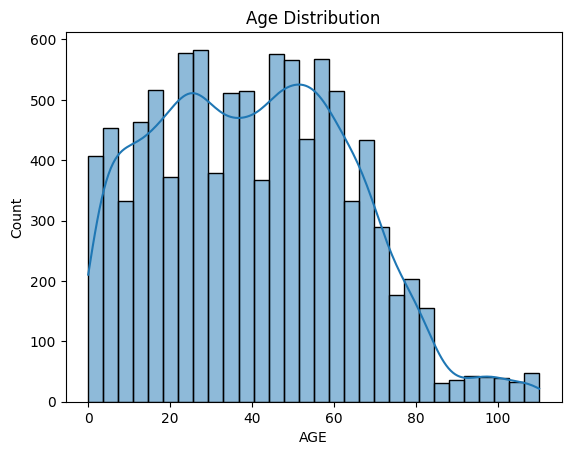

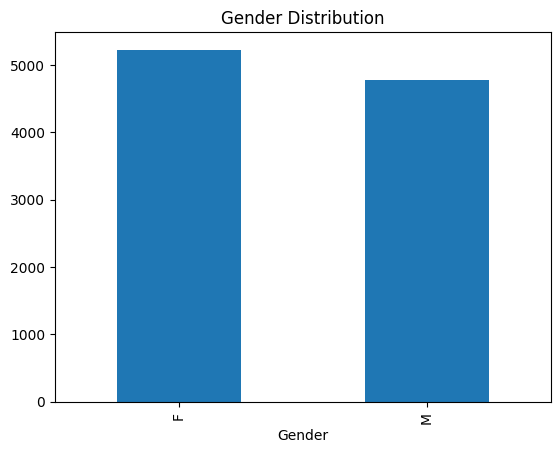

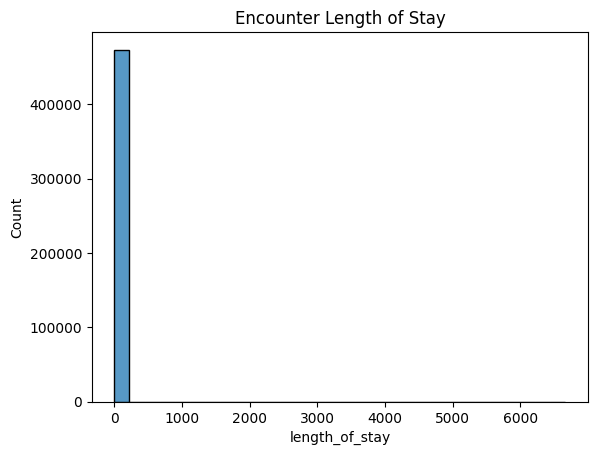

       Base_Encounter_Cost  Total_Claim_Cost
count        473685.000000     473685.000000
mean            115.928252       2715.675233
std              27.165344       5739.942676
min              75.000000          0.000000
25%              85.550000        516.950000
50%             136.800000        941.430000
75%             142.580000       2730.980000
max             146.180000     440652.250000

Top 10 Most Common Conditions:
Description
Medication review due (situation)\r    62965
Stress (finding)\r                     24732
Gingivitis (disorder)\r                24069
Full-time employment (finding)\r       22951
Part-time employment (finding)\r       14111
Viral sinusitis (disorder)\r           10265
Social isolation (finding)\r            8774
Limited social contact (finding)\r      8730
Not in labor force (finding)\r          7747
Gingival disease (disorder)\r           7093
Name: count, dtype: int64

Top 10 Medications:
Description
1 ML Epoetin Alfa 4000 UNT/ML Injection [E

In [2]:
# --- Patients table ---
print("\n=== Patients Summary ===")
print(patients.describe(include='all').T)

# Age distribution (approx)
patients['Birthdate'] = pd.to_datetime(patients['Birthdate'], errors='coerce')
patients['AGE'] = (pd.Timestamp('today') - patients['Birthdate']).dt.days // 365
sns.histplot(patients['AGE'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

# Gender distribution
patients['Gender'].value_counts().plot(kind='bar', title='Gender Distribution')
plt.show()

# --- Encounters ---
encounters['StartDT'] = pd.to_datetime(encounters['StartDT'], errors='coerce')
encounters['StopDT'] = pd.to_datetime(encounters['StopDT'], errors='coerce')

encounters['length_of_stay'] = (encounters['StopDT'] - encounters['StartDT']).dt.days
sns.histplot(encounters['length_of_stay'].dropna(), bins=30)
plt.title('Encounter Length of Stay')
plt.show()

print(encounters[['Base_Encounter_Cost', 'Total_Claim_Cost']].describe())

# --- Conditions ---
print("\nTop 10 Most Common Conditions:")
print(conditions['Description'].value_counts().head(10))

# --- Medications ---
print("\nTop 10 Medications:")
print(medications['Description'].value_counts().head(10))

# --- Observations ---
print("\nUnique Observation Types:")
print(observations['OBS_DESCRIPTION'].value_counts().head(10))


In [3]:
# Patients with encounters
patients_with_encounters = encounters['Patient'].nunique()
patients_with_conditions = conditions['Patient'].nunique()
patients_with_meds = medications['Patient'].nunique()
patients_with_obs = observations['Patient'].nunique()

print(f"Patients with Encounters: {patients_with_encounters}")
print(f"Patients with Conditions: {patients_with_conditions}")
print(f"Patients with Medications: {patients_with_meds}")
print(f"Patients with Observations: {patients_with_obs}")


Patients with Encounters: 9999
Patients with Conditions: 10000
Patients with Medications: 9738
Patients with Observations: 1831


In [4]:
def missing_report(df, name):
    miss = df.isna().mean().sort_values(ascending=False)
    print(f"\n=== Missing Values in {name} ===")
    print(miss[miss > 0].head(15))

for name, df in {
    'patients': patients,
    'encounters': encounters,
    'conditions': conditions,
    'medications': medications,
    'observations': observations
}.items():
    missing_report(df, name)



=== Missing Values in patients ===
Deathdate    1.000000
Income       1.000000
Marital      0.342234
dtype: float64

=== Missing Values in encounters ===
ReasonCode    0.401058
dtype: float64

=== Missing Values in conditions ===
StopDT    0.260652
dtype: float64

=== Missing Values in medications ===
ReasonCode    0.277172
StopDT        0.071719
dtype: float64

=== Missing Values in observations ===
ValueTxt           6.257133e-01
ValueNum           3.742867e-01
Units              2.998524e-01
Encounter          5.344571e-02
Category           5.344571e-02
OBS_DESCRIPTION    9.523810e-07
dtype: float64


In [5]:
# --- View basic structure ---
print("=== PATIENTS TABLE ===")
patients.info()
print("\n=== ENCOUNTERS TABLE ===")
encounters.info()
print("\n=== CONDITIONS TABLE ===")
conditions.info()
print("\n=== MEDICATIONS TABLE ===")
medications.info()
print("\n=== OBSERVATIONS TABLE ===")
observations.info()

=== PATIENTS TABLE ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Id                   9999 non-null   object        
 1   Birthdate            9999 non-null   datetime64[ns]
 2   Deathdate            0 non-null      object        
 3   Gender               9999 non-null   object        
 4   Race                 9999 non-null   object        
 5   Ethnicity            9999 non-null   object        
 6   Marital              6577 non-null   object        
 7   Income               0 non-null      object        
 8   Healthcare_Expenses  9999 non-null   float64       
 9   Healthcare_Coverage  9999 non-null   float64       
 10  City                 9999 non-null   object        
 11  State                9999 non-null   object        
 12  Zip                  9999 non-null   object        
 13  AGE       

In [18]:
df.columns

Index(['ObsDT', 'Patient', 'Encounter', 'Category', 'Code', 'OBS_DESCRIPTION',
       'ValueNum', 'ValueTxt', 'Units', 'OBS_TYPE'],
      dtype='object')

In [6]:
# Patients: drop identifiers not needed for ML
patients = patients.drop(columns=["Deathdate","Income"], errors='ignore')

# # Encounters: drop text identifiers
# encounters = encounters.drop(columns=[], errors='ignore')

# # Conditions: drop unused columns
# conditions = conditions.drop(columns=['SYSTEM'], errors='ignore')

# # Medications: drop unused identifiers
# medications = medications.drop(columns=['PAYER', 'REASONDESCRIPTION'], errors='ignore')

# # Observations: drop unused columns
# observations = observations.drop(columns=['CATEGORY', 'CODE', 'TYPE'], errors='ignore')

# Confirm changes
print("Patients columns:", patients.columns.tolist())
print("Encounters columns:", encounters.columns.tolist())


Patients columns: ['Id', 'Birthdate', 'Gender', 'Race', 'Ethnicity', 'Marital', 'Healthcare_Expenses', 'Healthcare_Coverage', 'City', 'State', 'Zip', 'AGE']
Encounters columns: ['Id', 'StartDT', 'StopDT', 'Patient', 'EncounterClass', 'Code', 'Description', 'Base_Encounter_Cost', 'Total_Claim_Cost', 'Payer_Coverage', 'ReasonCode', 'ReasonDescription', 'length_of_stay']


In [7]:
print("=== PATIENTS TABLE ===")
display(patients.describe().T)

print("\n=== ENCOUNTERS TABLE ===")
display(encounters.describe().T)

print("\n=== CONDITIONS TABLE ===")
display(conditions.describe().T)

print("\n=== MEDICATIONS TABLE ===")
display(medications.describe().T)

print("\n=== OBSERVATIONS TABLE ===")
display(observations.describe().T)


=== PATIENTS TABLE ===


,count,mean,min,25%,50%,75%,max,std
Birthdate,9999,1985-03-09 23:34:39.207920832,1914-12-30 00:00:00,1967-11-22 00:00:00,1985-09-06 00:00:00,2004-05-06 00:00:00,2025-10-26 00:00:00,NaN
Healthcare_Expenses,9999.0,174526.551105,100.0,21659.1,92188.33,214781.095,1820699.44,232630.583852
Healthcare_Coverage,9999.0,304256.622511,0.0,17399.675,134113.59,489383.95,3201889.41,386787.155338
AGE,9999.0,40.244924,0.0,21.0,40.0,58.0,110.0,23.614471



=== ENCOUNTERS TABLE ===


,count,mean,min,25%,50%,75%,max,std
StartDT,473685,2018-09-06 13:13:46.109389312,1915-12-02 17:08:05,2017-07-29 02:05:15,2020-09-16 03:13:45,2023-03-21 17:28:00,2025-11-01 15:00:26,NaN
StopDT,473685,2018-09-06 17:42:36.148305408,1915-12-02 17:23:05,2017-07-29 07:25:23,2020-09-16 07:39:08,2023-03-21 21:55:38,2025-11-01 17:55:26,NaN
Base_Encounter_Cost,473685.0,115.928252,75.0,85.55,136.8,142.58,146.18,27.165344
Total_Claim_Cost,473685.0,2715.675233,0.0,516.95,941.43,2730.98,440652.25,5739.942676
Payer_Coverage,473685.0,1910.52405,0.0,0.0,459.18,1393.68,261521.35,4724.710995
length_of_stay,473685.0,0.137515,0.0,0.0,0.0,0.0,6663.0,9.855942



=== CONDITIONS TABLE ===


,count,mean,min,25%,50%,75%,max
StartDT,327395,2017-05-25 01:00:19.671650560,1915-12-02 00:00:00,2016-07-31 00:00:00,2020-01-10 00:00:00,2022-12-02 00:00:00,2025-11-01 00:00:00
StopDT,242059,2021-01-28 01:43:06.445453312,2015-11-06 00:00:00,2018-09-11 00:00:00,2021-02-22 00:00:00,2023-07-11 00:00:00,2025-11-01 00:00:00



=== MEDICATIONS TABLE ===


,count,mean,min,25%,50%,75%,max,std
StartDT,328936,2020-08-28 16:19:33.911411200,1921-01-03 20:38:11,2018-07-01 00:33:22,2021-03-23 00:38:40,2023-08-28 06:27:19,2025-11-01 14:51:23,NaN
StopDT,305345,2021-04-23 23:12:16.139311360,2015-11-06 00:15:57,2018-12-20 16:40:23,2021-06-24 03:37:55,2023-10-18 20:51:43,2025-11-01 14:51:23,NaN
Base_Cost,328936.0,116.545188,0.0,0.91,45.86,129.94,103958.4,1432.706269
Payer_Coverage,328936.0,66.056633,0.0,0.0,0.73,79.94,103958.4,1147.576989
Dispenses,328936.0,9.589203,1.0,1.0,1.0,3.0,1276.0,49.737677
TotalCost,328936.0,4607.980293,0.0,3.6,91.72,238.92,46261488.0,296167.591159



=== OBSERVATIONS TABLE ===


,count,mean,min,25%,50%,75%,max,std
ObsDT,1050000,2021-02-21 10:59:40.089115648,2015-01-02 01:21:41,2018-10-08 03:19:53,2021-03-29 14:48:35,2023-08-12 20:17:31,2025-11-01 13:25:20,NaN
ValueNum,656999.0,2745.675148,-5.6,4.0,20.9,87.0,982894.0,31449.913715


In [8]:
print("=== PATIENTS TABLE ===")
display(patients.describe(include='object').T)

print("\n=== ENCOUNTERS TABLE ===")
display(encounters.describe(include='object').T)

print("\n=== CONDITIONS TABLE ===")
display(conditions.describe(include='object').T)

print("\n=== MEDICATIONS TABLE ===")
display(medications.describe(include='object').T)

print("\n=== OBSERVATIONS TABLE ===")
display(observations.describe(include='object').T)


=== PATIENTS TABLE ===


,count,unique,top,freq
Id,9999,9999,810FB8A8-2796-352D-2451-001CF4E44C09,1
Gender,9999,2,F,5224
Race,9999,6,white,8257
Ethnicity,9999,2,nonhispanic,8888
Marital,6577,4,M,4023
City,9999,407,Boston,926
State,9999,1,Massachusetts,9999
Zip,9999,326,00000,2579



=== ENCOUNTERS TABLE ===


,count,unique,top,freq
Id,473685,473685,48192B64-953C-9B16-BEF5-000006377C94,1
Patient,473685,9999,5BAB25B8-4AAF-741C-1C01-4ADC933C9285,842
EncounterClass,473685,10,ambulatory,237656
Code,473685,58,162673000,84850
Description,473685,58,General examination of patient (procedure),84850
ReasonCode,283710,165,431857002,38407
ReasonDescription,473685,166,\r,189975



=== CONDITIONS TABLE ===


,count,unique,top,freq
Patient,327395,10000,A2B86D07-0418-67F1-663E-507E9D28961E,523
Encounter,327395,210458,8E053955-E0EF-83A4-AEBC-9371E7E59CD5,12
System,327395,1,SNOMED-CT,327395
Code,327395,287,314529007,62965
Description,327395,287,Medication review due (situation)\r,62965



=== MEDICATIONS TABLE ===


,count,unique,top,freq
Patient,328936,9738,A2B86D07-0418-67F1-663E-507E9D28961E,2343
Payer,328936,10,A735BF55-83E9-331A-899D-A82A60B9F60C,134112
Encounter,328936,184291,7C739ECE-91E5-5498-2297-D5F2968F6B3D,46
Code,328936,325,205923,32776
Description,328936,335,1 ML Epoetin Alfa 4000 UNT/ML Injection [Epogen],32776
ReasonCode,237764,62,59621000,78548
ReasonDescription,328936,63,\r,91172



=== OBSERVATIONS TABLE ===


,count,unique,top,freq
Patient,1050000,1831,A2B86D07-0418-67F1-663E-507E9D28961E,23829
Encounter,993882,36813,54266F6B-D848-5DA0-0942-6A9BB1AC320F,781
Category,993882,8,laboratory,401321
Code,1050000,275,72514-3,28203
OBS_DESCRIPTION,1049999,291,Pain severity - 0-10 verbal numeric rating [Sc...,28203
ValueTxt,393001,1586,No,109161
Units,735155,51,mg/dL,131460
OBS_TYPE,1050000,2,numeric\r,640317


In [ ]:
patients.columns


In [9]:
# --- Helper function ---
def show_classes(df, name, max_show=15):
    print(f"\n=== TABLE: {name.upper()} ===")
    for col in df.columns:
        n_unique = df[col].nunique(dropna=True)
        print(f"\n🧩 Column: {col} — Unique values: {n_unique}")
        # If few unique values, show them
        if n_unique <= max_show:
            print(df[col].unique())
        else:
            print(f"  (Too many to display — showing top {max_show})")
            print(df[col].value_counts().head(max_show).index.tolist())

# --- Run for all tables ---
show_classes(patients, 'patients')
show_classes(encounters, 'encounters')
show_classes(conditions, 'conditions')
show_classes(medications, 'medications')
show_classes(observations, 'observations')


=== TABLE: PATIENTS ===

🧩 Column: Id — Unique values: 9999
  (Too many to display — showing top 15)
['810FB8A8-2796-352D-2451-001CF4E44C09', '0B52AE72-9D3F-1439-9971-001E334F1CB8', '4EA61B89-92CA-63A6-74AB-001E88EF165F', 'CDA9AE96-817D-A530-9208-001ECCD9EFC4', '2EC48B13-9EF3-2011-59AE-0022921A2C5C', '217C8E16-E57F-FE69-C37D-003BE2C3956D', '05555DC9-5D43-DCE9-1722-0041A384CAD8', '53B96E39-963A-DEF6-EFEC-00425639D2C9', 'FAD86207-4C98-37AB-B07B-004B7065AFFF', 'B491D03A-4B44-E6AD-84FC-004F0C7DD9A6', 'A2286DC6-CE3C-05DF-0CC9-0058D6C839CF', '6CF6751F-3A93-EE29-E40D-00638BA52BCA', 'B371525C-035B-755E-B93D-0066F2977CC7', '2D6CBAFD-5A58-F7F8-9C8F-006D393BAF3B', 'EBC283AB-0C98-B302-22BC-006E770B4FD9']

🧩 Column: Birthdate — Unique values: 8540
  (Too many to display — showing top 15)
[Timestamp('1994-04-27 00:00:00'), Timestamp('1990-12-02 00:00:00'), Timestamp('1948-12-05 00:00:00'), Timestamp('2007-03-17 00:00:00'), Timestamp('2009-08-26 00:00:00'), Timestamp('1956-12-22 00:00:00'), Timestam

In [12]:
# ================================================
# STEP 2: LABEL CREATION + FEATURE ENGINEERING
# ================================================

import pandas as pd
import numpy as np

# --- 1. Define list of chronic condition keywords ---
chronic_keywords = [
    'hypertension', 'diabetes', 'asthma', 'heart', 'cardio', 
    'chronic', 'arthritis', 'obesity', 'renal', 'copd', 
    'hyperlipidemia', 'stroke', 'cancer', 'disease'
]

# --- 2. Flag chronic conditions ---
conditions['is_chronic'] = conditions['Description'].str.lower().apply(
    lambda x: any(k in str(x) for k in chronic_keywords)
)

# --- 3. Get first chronic diagnosis date per patient ---
chronic_onset = (
    conditions[conditions['is_chronic']]
    .groupby('Patient')['StartDT']
    .min()
    .rename('chronic_onset_date')
)

# --- 4. Get first encounter date per patient ---
first_encounter = (
    encounters.groupby('Patient')['StartDT']
    .min()
    .rename('first_encounter_date')
)

# --- 5. Merge and create label ---
labels_df = pd.concat([first_encounter, chronic_onset], axis=1)
labels_df['developed_chronic_1yr'] = (
    (pd.to_datetime(labels_df['chronic_onset_date']) - 
     pd.to_datetime(labels_df['first_encounter_date']))
    .dt.days
    .between(0, 1825)
).astype(int)

labels_df.reset_index(inplace=True)
labels_df.rename(columns={'index': 'Patient'}, inplace=True)

print("✅ Label table created:")
print(labels_df['developed_chronic_1yr'].value_counts())

# --- 6. Build patient-level features ---

## Encounters: frequency and cost
enc_features = (
    encounters.groupby('Patient').agg({
        'Id': 'count',
        'Base_Encounter_Cost': 'mean',
        'Total_Claim_Cost': 'mean',
        'length_of_stay': 'mean'
    })
    .rename(columns={
        'Id': 'encounter_count',
        'Base_Encounter_Cost': 'avg_base_cost',
        'Total_Claim_Cost': 'avg_claim_cost',
        'length_of_stay': 'avg_stay'
    })
)

## Medications: counts and cost
med_features = (
    medications.groupby('Patient').agg({
        'Description': 'count',
        'TotalCost': 'mean',
        'Dispenses': 'mean'
    })
    .rename(columns={
        'Description': 'num_meds',
        'TotalCost': 'avg_med_cost',
        'Dispenses': 'avg_dispenses'
    })
)

## Conditions: counts and chronic ratio
cond_features = (
    conditions.groupby('Patient').agg({
        'Description': 'count',
        'is_chronic': 'mean'
    })
    .rename(columns={
        'Description': 'num_conditions',
        'is_chronic': 'chronic_ratio'
    })
)

## Observations: average numeric values
obs_features = (
    observations.groupby('Patient')['ValueNum']
    .mean()
    .rename('avg_observation_value')
)

# --- 7. Merge all features into one dataset ---
features_df = (
    patients.set_index('Id')
    .join(enc_features)
    .join(med_features)
    .join(cond_features)
    .join(obs_features)
    .join(labels_df.set_index('Patient'))
)

# --- 8. Keep useful columns only ---
features_df = features_df[[
    'AGE', 'Gender', 'Race', 'Ethnicity', 'Marital',
    'Healthcare_Expenses', 'Healthcare_Coverage',
    'encounter_count', 'avg_base_cost', 'avg_claim_cost', 'avg_stay',
    'num_meds', 'avg_med_cost', 'avg_dispenses',
    'num_conditions', 'chronic_ratio', 'avg_observation_value',
    'developed_chronic_1yr'
]]

print("\n✅ Final feature dataset created. Shape:", features_df.shape)
features_df.head()


✅ Label table created:
developed_chronic_1yr
0    8129
1    1870
Name: count, dtype: int64

✅ Final feature dataset created. Shape: (9999, 18)


,AGE,Gender,Race,Ethnicity,Marital,Healthcare_Expenses,Healthcare_Coverage,encounter_count,avg_base_cost,avg_claim_cost,avg_stay,num_meds,avg_med_cost,avg_dispenses,num_conditions,chronic_ratio,avg_observation_value,developed_chronic_1yr
Id,,,,,,,,,,,,,,,,,,
810FB8A8-2796-352D-2451-001CF4E44C09,49,F,white,nonhispanic,D,300947.24,973955.08,34,128.288824,4106.872059,0.000000,13.0,3831.859231,52.307692,30,0.033333,NaN,0
0B52AE72-9D3F-1439-9971-001E334F1CB8,51,F,white,nonhispanic,M,593234.58,448553.87,58,125.514483,2208.505862,0.000000,51.0,648.691961,4.764706,48,0.104167,NaN,0
4EA61B89-92CA-63A6-74AB-001E88EF165F,20,F,asian,nonhispanic,None,5389.85,196602.10,35,131.728571,4487.236857,0.342857,46.0,675.475870,1.956522,35,0.085714,49.155449,1
CDA9AE96-817D-A530-9208-001ECCD9EFC4,71,F,white,nonhispanic,D,778288.43,154511.33,48,114.692292,2350.908542,0.062500,37.0,257.221622,3.513514,44,0.113636,NaN,0
2EC48B13-9EF3-2011-59AE-0022921A2C5C,17,M,black,nonhispanic,None,55290.39,1076.61,25,112.662400,1545.946800,0.000000,3.0,129.940000,1.000000,17,0.117647,52.823490,1


Numeric columns: ['AGE', 'Healthcare_Expenses', 'Healthcare_Coverage', 'encounter_count', 'avg_base_cost', 'avg_claim_cost', 'avg_stay', 'num_meds', 'avg_med_cost', 'avg_dispenses', 'num_conditions', 'chronic_ratio', 'avg_observation_value']
Categorical columns: ['Gender', 'Race', 'Ethnicity', 'Marital']
Train size: 6998, Validation size: 1501, Test size: 1500

=== Model Comparison ===


,Model,Train_Acc,Val_Acc,Test_Acc,Train_AUC,Val_AUC,Test_AUC
0,RandomForest,1.000,0.838,0.827,1.000,0.788,0.774
1,XGBoost,0.920,0.840,0.814,0.986,0.781,0.766
2,LogisticRegression,0.677,0.694,0.669,0.726,0.727,0.720


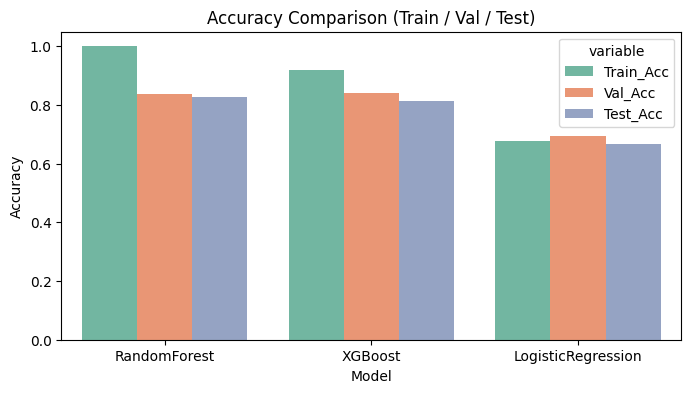

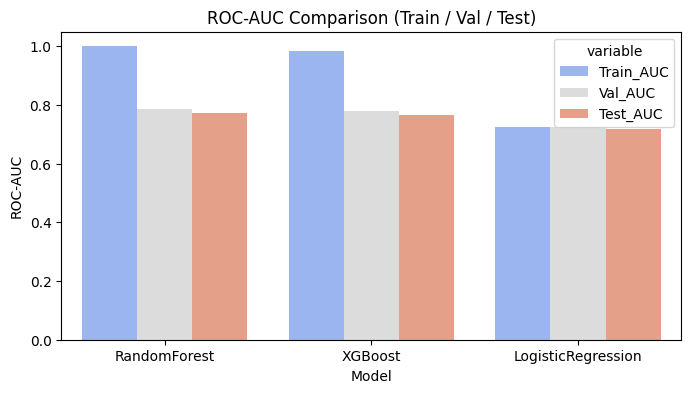


Best Model by Validation AUC: RandomForest

=== Final Classification Report (Test Set) ===
              precision    recall  f1-score   support

           0       0.85      0.97      0.90      1219
           1       0.63      0.26      0.36       281

    accuracy                           0.83      1500
   macro avg       0.74      0.61      0.63      1500
weighted avg       0.81      0.83      0.80      1500



In [17]:
# ==================================================
# STEP 4: TRAIN/VAL/TEST SPLIT + MULTI-MODEL COMPARISON
# ==================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer



# Identify which columns are numeric vs categorical
numeric_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object','category']).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)


# --- Preprocessing ---
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# --- 4. Split Train / Validation / Test ---
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)
# (70% train, 15% val, 15% test)

print(f"Train size: {len(X_train)}, Validation size: {len(X_val)}, Test size: {len(X_test)}")

# --- 5. Define models ---
models = {
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1),
    "XGBoost": XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', random_state=42
    ),
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1)
}

# --- 6. Train and evaluate each model ---
results = []

for name, model in models.items():
    clf = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    clf.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = clf.predict(X_train)
    y_val_pred = clf.predict(X_val)
    y_test_pred = clf.predict(X_test)
    
    # Probabilities for ROC-AUC
    y_train_proba = clf.predict_proba(X_train)[:,1]
    y_val_proba = clf.predict_proba(X_val)[:,1]
    y_test_proba = clf.predict_proba(X_test)[:,1]
    
    # Scores
    acc_train = accuracy_score(y_train, y_train_pred)
    acc_val = accuracy_score(y_val, y_val_pred)
    acc_test = accuracy_score(y_test, y_test_pred)
    auc_train = roc_auc_score(y_train, y_train_proba)
    auc_val = roc_auc_score(y_val, y_val_proba)
    auc_test = roc_auc_score(y_test, y_test_proba)
    
    results.append({
        "Model": name,
        "Train_Acc": acc_train, "Val_Acc": acc_val, "Test_Acc": acc_test,
        "Train_AUC": auc_train, "Val_AUC": auc_val, "Test_AUC": auc_test
    })

# --- 7. Results summary ---
results_df = pd.DataFrame(results)
print("\n=== Model Comparison ===")
display(results_df.round(3))

# --- 8. Plot results ---
plt.figure(figsize=(8,4))
sns.barplot(data=results_df.melt(id_vars='Model', value_vars=['Train_Acc','Val_Acc','Test_Acc']),
            x='Model', y='value', hue='variable', palette='Set2')
plt.title("Accuracy Comparison (Train / Val / Test)")
plt.ylabel("Accuracy")
plt.show()

plt.figure(figsize=(8,4))
sns.barplot(data=results_df.melt(id_vars='Model', value_vars=['Train_AUC','Val_AUC','Test_AUC']),
            x='Model', y='value', hue='variable', palette='coolwarm')
plt.title("ROC-AUC Comparison (Train / Val / Test)")
plt.ylabel("ROC-AUC")
plt.show()

# --- 9. Optional: print best model’s classification report ---
best_model_name = results_df.sort_values('Val_AUC', ascending=False).iloc[0]['Model']
print(f"\nBest Model by Validation AUC: {best_model_name}")

best_model = Pipeline(steps=[('preprocessor', preprocessor), ('model', models[best_model_name])])
best_model.fit(pd.concat([X_train, X_val]), pd.concat([y_train, y_val]))

y_pred_final = best_model.predict(X_test)
print("\n=== Final Classification Report (Test Set) ===")
print(classification_report(y_test, y_pred_final))


In [30]:
# ===============================================
# SAVE TRAINED MODEL & PREPROCESSOR PIPELINE
# ===============================================
import joblib, os

os.makedirs("models", exist_ok=True)
joblib.dump(best_model, "models/chronic_disease_predictor.pkl")

print("✅ Model and preprocessor saved successfully at: models/chronic_disease_predictor.pkl")


✅ Model and preprocessor saved successfully at: models/chronic_disease_predictor.pkl
